# Looking at our Yelp Dataset

### References:
- For some of the data visualization: 
- Perform Sentiment Analysis on Twitter data by combining Text Mining and NLP techniques, NLTK and Scikit-Learn
- by Benjamin Termonia
- provided by Udemy Business

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/yelp_data/updated_yelp_polarity_train.csv')
# only top 5000 rows
df = df.head(10000)

# number of items in the dataset & checking for missing values
print(len(df))
df = df.dropna()
print(len(df))

10000
10000


In [3]:
# Showing a sample of the data 
df.sample(10)

,sentiment,text
5721,positive,My wife and I always enjoy our meals at Blue. ...
4483,negative,Bad food. Bug problem. In a neighborhood full ...
1901,negative,Meh. \n\nClam chowder was big and OK. Veggie ...
8324,negative,Was here for a gala at the adjoining conferenc...
2850,positive,The secret in their having one of the best bur...
9316,positive,"Cheddar burger, check. Vanilla shake, check. F..."
7083,positive,Around 10 of my friends already have their hon...
4348,negative,This is a review of their business practices o...
6813,negative,Dead Roach on the Bamboo on my steam dumpling ...
8314,positive,Stopped in for a drink on Monday night. A few ...


## Visualize the data

In [4]:
import matplotlib.pyplot as plt

           text
sentiment      
negative   5293
positive   4707


<BarContainer object of 2 artists>

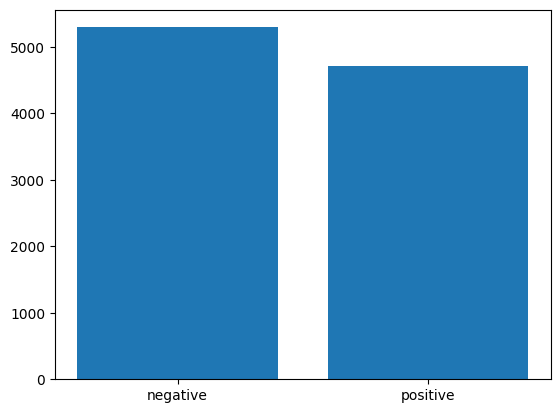

In [5]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['text'])

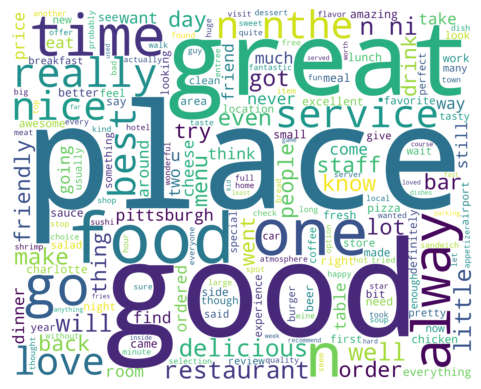

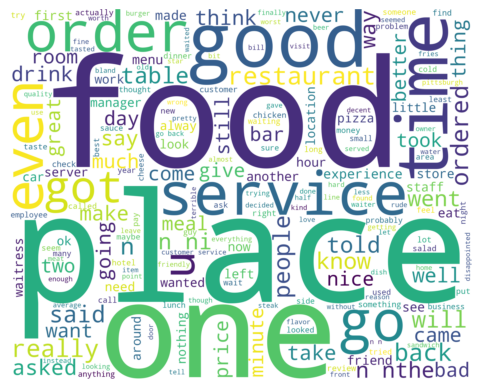

In [6]:
# Visualizing most commonly used words in the negative and positive reviews
from wordcloud import WordCloud

positive_text = df[df['sentiment'] == 'positive']
negative_text = df[df['sentiment'] == 'negative']

txt_positive = " ".join(text.lower() for text in positive_text['text'])
txt_negative = " ".join(text.lower() for text in negative_text['text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()

# Text processing

In [7]:
'''
This file contains the functions needed to normalize the data from its respective dataset. These are the following steps in the normalization process:
1. Convert emojis to text
2. Remove links
3. Remove hashtags
4. Make all text lowercase
5. Removing repeated characters
6. Removing punctuation repetitions
7. Replacing contractions with their expanded form

References:
- Perform Sentiment Analysis on Twitter data by combining Text Mining and NLP techniques, NLTK and Scikit-Learn
- by Benjamin Termonia
- provided by Udemy Business
'''
import re # Used for regex
import emoji # Used to convert emojis to text

import contractions # Used to expand contractions

import nltk
import ssl # Used to fix SSL error when downloading nltk data

'''
Error handling for nltk download and issue with SSL
Reference: https://stackoverflow.com/questions/38916452/nltk-download-ssl-certificate-verify-failed
    and https://github.com/gunthercox/ChatterBot/issues/930#issuecomment-322111087
'''
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

from nltk.tokenize import word_tokenize
nltk.download('punkt')

import string
from nltk.corpus import stopwords
nltk.download('stopwords')

# Stemming
from nltk.stem import PorterStemmer 
from nltk.stem import LancasterStemmer # more agressive stemming
from nltk.stem import SnowballStemmer # better than porter and newer

# Remove emojis
def convert_emoji_to_text(text):
    text = emoji.demojize(text) # Converting the emoji to their word meaning
    text = text.replace(":"," ") # Replacing the colon symbol with a space
    return text

# Remove links
def remove_links(text, replace_with=""):
    text = re.sub('(http|https):\/\/\S+', replace_with, text) # regex to remove any links starting with http or https
    return text

# Remove hashtags
def remove_hashtags(text, replace_with=""):
    text = re.sub('#+', replace_with, text) # regex to remove any hashtags
    return text


# Make all text lowercase
def lower_case_string(text):
    return text.lower()


# Removing repeated characters
def remove_letter_repetitions(text):
    return re.sub(r'(.)\1+', r'\1\1', text) # regex to remove repeated chars, firstly matches a char which is repeated more than once, then replaces it with the same char twice

# Removing punctuation repetitions
def remove_punctuation_repetitions(text, replace_with=""):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', replace_with, text) # regex to remove repeated punctuation, firstly matches a punctuation which is repeated more than once, then replaces it with a single punctuation

'''
Replacing contractions with their expanded form
'''
# Replacing contractions with their full form: e.g I'm -> I am
def replace_contractions(text):
    text = contractions.fix(text) # Using built in method from contractions library
    return text

# Depending if we want to keep punctuation, alphanumeric characters and stopwords we can use the following function with True or False
def custom_tokenization(text, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False):
    stop_words = set(stopwords.words('english')) # Getting the stop words from nltk
    token_list = word_tokenize(text)

    if not keep_punctuation:
        token_list = [token for token in token_list if token not in string.punctuation] # Add only if not in the punctuation list
    if not keep_alphanum:
        token_list = [token for token in token_list if token.isalpha()] # Add only if is a letter
    if not keep_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.discard('not') # Remove stop words which are relevant for sentiment analysis from the stop words list !NOTE: Can add more words to be excluded
        token_list = [token for token in token_list if token not in stop_words] # Add only if not in the stop words list

    return token_list

# Function to stem tokens given a stemming algorithm, e.g. porter, lancaster, snowball
def stemming_tokens(tokens, stemmer):
    # depending on the chosen stemmer, we will use the respective stemming algorithm
    if stemmer == 'porter':
        stemmer = PorterStemmer()
    elif stemmer == 'lancaster':
        stemmer = LancasterStemmer()
    elif stemmer == 'snowball':
        stemmer = SnowballStemmer('english')
    else:
        raise ValueError('Stemmer not recognized - please choose between porter, lancaster or snowball.')

    # Stemming the tokens using specified stemmer
    token_list = [stemmer.stem(token) for token in tokens] # Add the new stemmed token to the list
    return token_list

# Function to process the text, removing links, converting emojis to text, removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
def process_text(text):
    # Removing links and converting emojis to text
    p_txt = remove_links(text)
    p_txt = convert_emoji_to_text(p_txt)

    # Removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
    p_txt = remove_hashtags(p_txt)
    p_txt = lower_case_string(p_txt)
    p_txt = remove_letter_repetitions(p_txt)
    p_txt = remove_punctuation_repetitions(p_txt)
    p_txt = replace_contractions(p_txt)
    
    # Tokenizing the string
    p_txt = custom_tokenization(p_txt)

    # Stemming the tokens, using the snowball stemmer
    p_txt = stemming_tokens(p_txt, 'snowball')
    return p_txt

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Dataset manipulation

In [8]:
# apply the process_text function to the tweet_text column
df["tokens"] = df["text"].apply(process_text)

# change sentiment to 1 or 0
df["text_sentiment"] = df["sentiment"].apply(lambda x: 1 if x == "positive" else 0)

In [9]:
x  = df["tokens"].tolist()
y = df["text_sentiment"].tolist()

In [10]:
def custom_preprocessor(text):
    return text

def custom_tokenizer(text):
    return text

# Fitting CV and TF-IDF

In [11]:
corpus = x # corpus is the text tokens of whole dataset

# BAG OF WORDS (CountVectorizer)
def fit_cv(text_corpus):
    cv_vect = CountVectorizer(tokenizer=custom_tokenizer, preprocessor=custom_preprocessor) # Using custom tokenizer and preprocessor

    cv_vect.fit(text_corpus)

    return cv_vect

# TF-IDF (TfidfVectorizer)
def fit_tfidf(text_corpus):
    tf_vect = TfidfVectorizer(preprocessor=custom_preprocessor, tokenizer=custom_tokenizer) # Using custom tokenizer and preprocessor

    tf_vect.fit(text_corpus) # fit the vectorizer on the corpus
    return tf_vect

cv_vect = fit_cv(corpus)

ft = cv_vect.get_feature_names_out()

print(ft)

tf_vect = fit_tfidf(corpus)
tf_mtx = tf_vect.transform(corpus)

/opt/homebrew/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


['aa' 'aahh' 'aahperd' ... 'zumba' 'zuppa' 'zwei']


# Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
import random

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0, train_size=0.8)

# Fitting the models

In [13]:
### Fitting the model

# Logistic Regression model
def fit_lr(x_train, y_train): # Fitting a logistic regression model
    lr = LogisticRegression()
    lr.fit(x_train, y_train)
    return lr

# Naive Bayes model
def fit_nb(x_train, y_train):
    nb = MultinomialNB()
    nb.fit(x_train, y_train)
    return nb

# Support Vector Machine model
def fit_svm(x_train, y_train):
    svm = SVC()
    svm.fit(x_train, y_train)
    return svm

# Random Forest model
def fit_rf(x_train, y_train):
    rf = RandomForestClassifier()
    rf.fit(x_train, y_train)
    return rf

# Gradient Boosting Machine model
def fit_gbm(x_train, y_train):
    gbm = GradientBoostingClassifier()
    gbm.fit(x_train, y_train)
    return gbm

# Using CV for all models

In [14]:
cv = fit_cv(x_train) # only fit on the training data
x_train_cv = cv.transform(x_train) # transform the training data
x_test_cv = cv.transform(x_test) # transform the testing data


model_lr_cv = fit_lr(x_train_cv, y_train) # fit the model on the training data ### logistic regression
model_nb_cv = fit_nb(x_train_cv, y_train) # fit the model on the training data ### naive bayes
model_svm_cv = fit_svm(x_train_cv, y_train) # fit the model on the training data ### support vector machine
model_rf_cv = fit_rf(x_train_cv, y_train) # fit the model on the training data ### random forest
model_gbm_cv = fit_gbm(x_train_cv, y_train) # fit the model on the training data ### gradient boosting machine


/opt/homebrew/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Using TF-IDF for all models

In [15]:
tf = fit_tfidf(x_train) # only fit on the training data
x_train_tf = tf.transform(x_train) # transform the training data
x_test_tf = tf.transform(x_test) # transform the testing data

model_lr_tf = fit_lr(x_train_tf, y_train) # fit the model on the training data ### logistic regression
model_nb_tf = fit_nb(x_train_tf, y_train) # fit the model on the training data ### naive bayes
model_svm_tf = fit_svm(x_train_tf, y_train) # fit the model on the training data ### support vector machine
model_rf_tf = fit_rf(x_train_tf, y_train) # fit the model on the training data ### random forest
model_gbm_tf = fit_gbm(x_train_tf, y_train) # fit the model on the training data ### gradient boosting machine


/opt/homebrew/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


# Performance metrics

## CV using all models

Accuracy of the model using CountVectorizer and Logistic Regression:  0.8835


<Axes: >

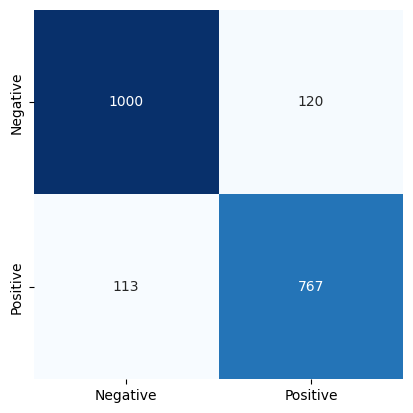

In [16]:
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

y_predict_lr_cv = model_lr_cv.predict(x_test_cv)
y_predict_nb_cv = model_nb_cv.predict(x_test_cv)
y_predict_svm_cv = model_svm_cv.predict(x_test_cv)
y_predict_rf_cv = model_rf_cv.predict(x_test_cv)
y_predict_gbm_cv = model_gbm_cv.predict(x_test_cv)

### CV - Logistic Regression

print("Accuracy of the model using CountVectorizer and Logistic Regression: ", accuracy_score(y_test, y_predict_lr_cv))

conf_matrix_lr_cv = confusion_matrix(y_test, y_predict_lr_cv)

sns.heatmap(conf_matrix_lr_cv, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])



Accuracy of the model using CountVectorizer and Naive Bayes:  0.866


<Axes: >

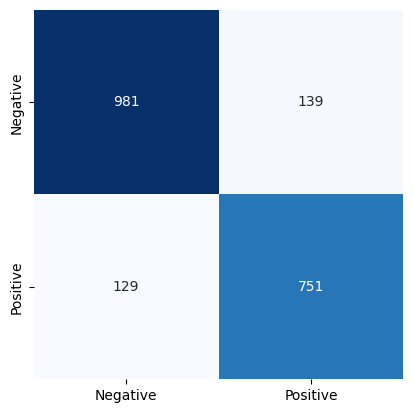

In [17]:
### CV - Naive Bayes
print("Accuracy of the model using CountVectorizer and Naive Bayes: ", accuracy_score(y_test, y_predict_nb_cv))

conf_matrix_nb_cv = confusion_matrix(y_test, y_predict_nb_cv)

sns.heatmap(conf_matrix_nb_cv, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])


Accuracy of the model using CountVectorizer and Support Vector Machine:  0.8685


<Axes: >

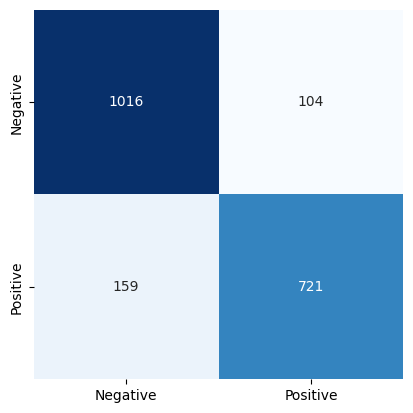

In [18]:
### CV - Support Vector Machine
print("Accuracy of the model using CountVectorizer and Support Vector Machine: ", accuracy_score(y_test, y_predict_svm_cv))

conf_matrix_svm_cv = confusion_matrix(y_test, y_predict_svm_cv)

sns.heatmap(conf_matrix_svm_cv, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])



Accuracy of the model using CountVectorizer and Random Forest:  0.857


<Axes: >

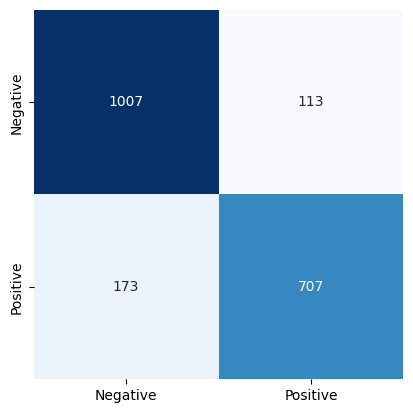

In [19]:
### CV - Random Forest
print("Accuracy of the model using CountVectorizer and Random Forest: ", accuracy_score(y_test, y_predict_rf_cv))

conf_matrix_rf_cv = confusion_matrix(y_test, y_predict_rf_cv)

sns.heatmap(conf_matrix_rf_cv, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])



Accuracy of the model using CountVectorizer and Gradient Boosting Machine:  0.8355


<Axes: >

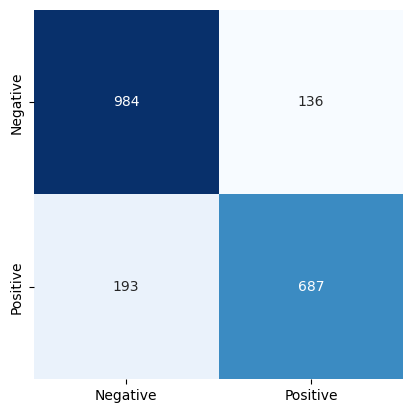

In [20]:
### CV - Gradient Boosting Machine
print("Accuracy of the model using CountVectorizer and Gradient Boosting Machine: ", accuracy_score(y_test, y_predict_gbm_cv))

conf_matrix_gbm_cv = confusion_matrix(y_test, y_predict_gbm_cv)

sns.heatmap(conf_matrix_gbm_cv, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])


## TF-IDF using all models

In [21]:
y_predict_lr_tf = model_lr_tf.predict(x_test_tf)
y_predict_nb_tf = model_nb_tf.predict(x_test_tf)
y_predict_svm_tf = model_svm_tf.predict(x_test_tf)
y_predict_rf_tf = model_rf_tf.predict(x_test_tf)
y_predict_gbm_tf = model_gbm_tf.predict(x_test_tf)



Accuracy of the model using TfidfVectorizer and Logistic Regression:  0.89


<Axes: >

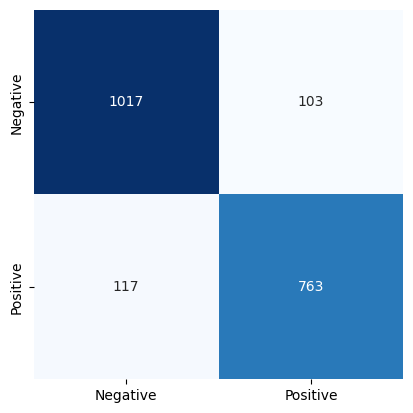

In [22]:
### TF - Logistic Regression
print("Accuracy of the model using TfidfVectorizer and Logistic Regression: ", accuracy_score(y_test, y_predict_lr_tf))

conf_matrix_lr_tf = confusion_matrix(y_test, y_predict_lr_tf)

sns.heatmap(conf_matrix_lr_tf, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

Accuracy of the model using TfidfVectorizer and Naive Bayes:  0.866


<Axes: >

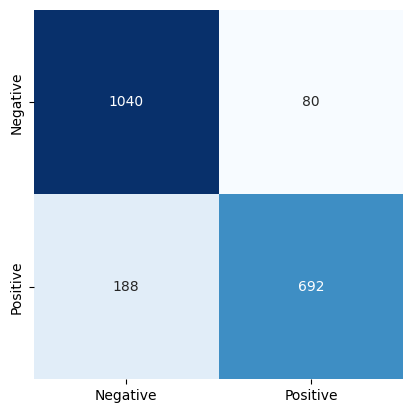

In [23]:
### TF - Naive Bayes
print("Accuracy of the model using TfidfVectorizer and Naive Bayes: ", accuracy_score(y_test, y_predict_nb_tf))

conf_matrix_nb_tf = confusion_matrix(y_test, y_predict_nb_tf)

sns.heatmap(conf_matrix_nb_tf, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

Accuracy of the model using TfidfVectorizer and Support Vector Machine:  0.895


<Axes: >

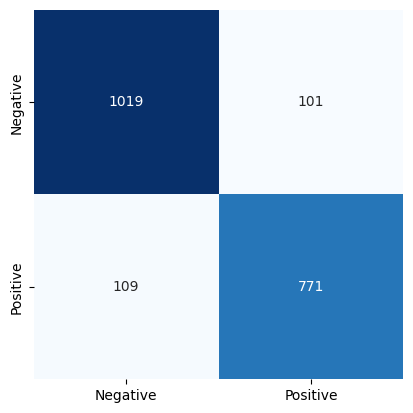

In [24]:
### TF - Support Vector Machine
print("Accuracy of the model using TfidfVectorizer and Support Vector Machine: ", accuracy_score(y_test, y_predict_svm_tf))

conf_matrix_svm_tf = confusion_matrix(y_test, y_predict_svm_tf)

sns.heatmap(conf_matrix_svm_tf, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

Accuracy of the model using TfidfVectorizer and Random Forest:  0.8575


<Axes: >

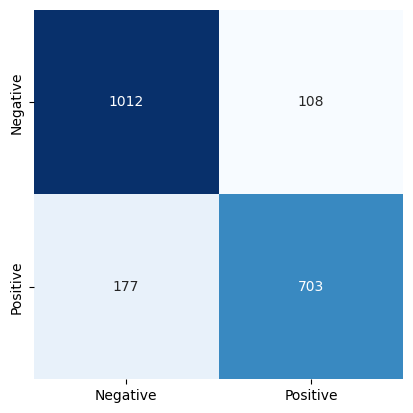

In [25]:
### TF - Random Forest
print("Accuracy of the model using TfidfVectorizer and Random Forest: ", accuracy_score(y_test, y_predict_rf_tf))

conf_matrix_rf_tf = confusion_matrix(y_test, y_predict_rf_tf)

sns.heatmap(conf_matrix_rf_tf, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

Accuracy of the model using TfidfVectorizer and Gradient Boosting Machine:  0.832


<Axes: >

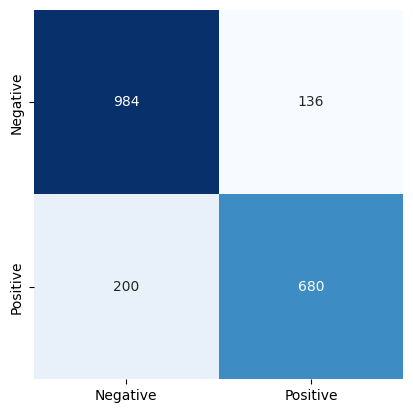

In [26]:
### TF - Gradient Boosting Machine
print("Accuracy of the model using TfidfVectorizer and Gradient Boosting Machine: ", accuracy_score(y_test, y_predict_gbm_tf))

conf_matrix_gbm_tf = confusion_matrix(y_test, y_predict_gbm_tf)

sns.heatmap(conf_matrix_gbm_tf, square=True, annot=True, cmap='Blues', fmt='d', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])

In [34]:
### Count of all the confusion matrices
# Format of the result
print("--- Count Vectorization ---")

print("Logistic Regression:\n", conf_matrix_lr_cv)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_lr_cv[0][1] + conf_matrix_lr_cv[1][0])
print("Total true postives and true negatives: ", conf_matrix_lr_cv[0][0] + conf_matrix_lr_cv[1][1])

print("Naive Bayes:\n", conf_matrix_nb_cv)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_nb_cv[0][1] + conf_matrix_nb_cv[1][0])
print("Total true postives and true negatives: ", conf_matrix_nb_cv[0][0] + conf_matrix_nb_cv[1][1])

print("Support Vector Machine:\n", conf_matrix_svm_cv)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_svm_cv[0][1] + conf_matrix_svm_cv[1][0])
print("Total true postives and true negatives: ", conf_matrix_svm_cv[0][0] + conf_matrix_svm_cv[1][1])

print("Random Forest:\n", conf_matrix_rf_cv)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_rf_cv[0][1] + conf_matrix_rf_cv[1][0])
print("Total true postives and true negatives: ", conf_matrix_rf_cv[0][0] + conf_matrix_rf_cv[1][1])

print("Gradient Boosting Machine:\n", conf_matrix_gbm_cv)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_gbm_cv[0][1] + conf_matrix_gbm_cv[1][0])
print("Total true postives and true negatives: ", conf_matrix_gbm_cv[0][0] + conf_matrix_gbm_cv[1][1])

print("--------------------------------")
print("--- Tfidf Vectorization ---")

print("Logistic Regression:\n", conf_matrix_lr_tf)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_lr_tf[0][1] + conf_matrix_lr_tf[1][0])
print("Total true postives and true negatives: ", conf_matrix_lr_tf[0][0] + conf_matrix_lr_tf[1][1])

print("Naive Bayes:\n", conf_matrix_nb_tf)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_nb_tf[0][1] + conf_matrix_nb_tf[1][0])
print("Total true postives and true negatives: ", conf_matrix_nb_tf[0][0] + conf_matrix_nb_tf[1][1])

print("Support Vector Machine:\n", conf_matrix_svm_tf)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_svm_tf[0][1] + conf_matrix_svm_tf[1][0])
print("Total true postives and true negatives: ", conf_matrix_svm_tf[0][0] + conf_matrix_svm_tf[1][1])

print("Random Forest:\n", conf_matrix_rf_tf)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_rf_tf[0][1] + conf_matrix_rf_tf[1][0])
print("Total true postives and true negatives: ", conf_matrix_rf_tf[0][0] + conf_matrix_rf_tf[1][1])

print("Gradient Boosting Machine:\n", conf_matrix_gbm_tf)
# showing the combined numbers of the confusion matrix
print("Total false postives and false negatives: ", conf_matrix_gbm_tf[0][1] + conf_matrix_gbm_tf[1][0])
print("Total true postives and true negatives: ", conf_matrix_gbm_tf[0][0] + conf_matrix_gbm_tf[1][1])



--- Count Vectorization ---
Logistic Regression:
 [[1000  120]
 [ 113  767]]
Total false postives and false negatives:  233
Total true postives and true negatives:  1767
Naive Bayes:
 [[981 139]
 [129 751]]
Support Vector Machine:
 [[1016  104]
 [ 159  721]]
Random Forest:
 [[1007  113]
 [ 173  707]]
Gradient Boosting Machine:
 [[984 136]
 [193 687]]
--------------------------------
--- Tfidf Vectorization ---
Logistic Regression:
 [[1017  103]
 [ 117  763]]
Naive Bayes:
 [[1040   80]
 [ 188  692]]
Support Vector Machine:
 [[1019  101]
 [ 109  771]]
Random Forest:
 [[1012  108]
 [ 177  703]]
Gradient Boosting Machine:
 [[984 136]
 [200 680]]


## Comparison of all models and vectorization

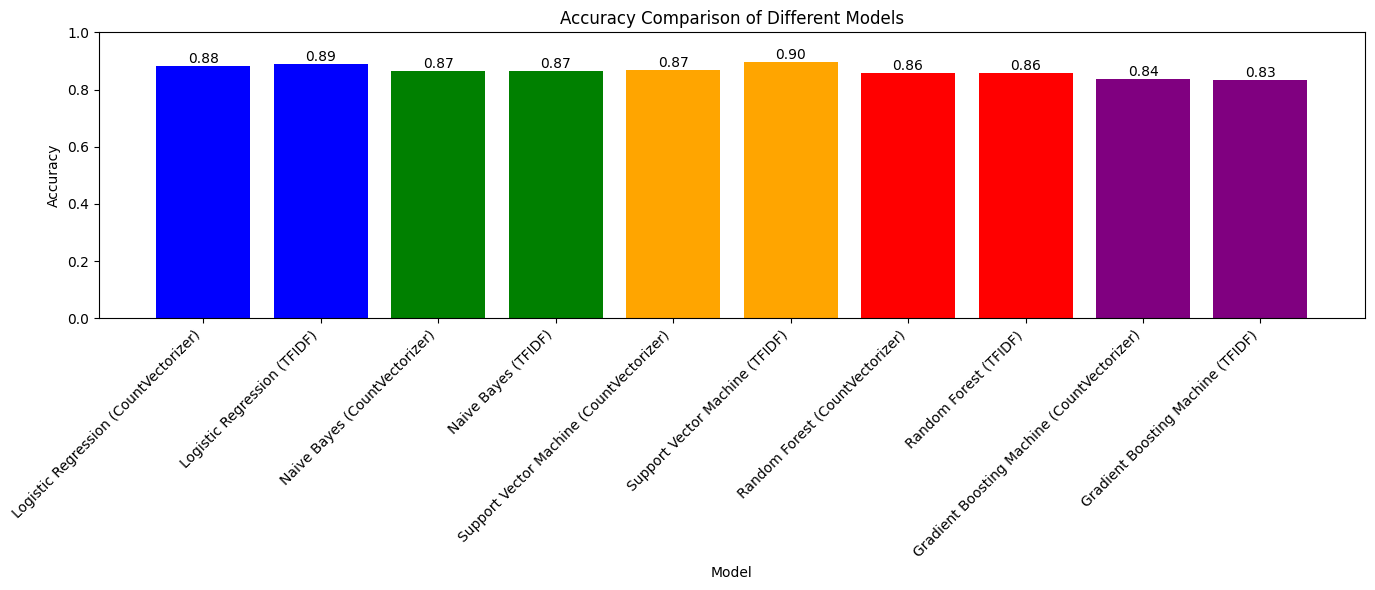

In [28]:
# Note: After this block of code, there is a reference
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define colors for each model
model_colors = {
    'Logistic Regression': 'blue',
    'Naive Bayes': 'green',
    'Support Vector Machine': 'orange',
    'Random Forest': 'red',
    'Gradient Boosting Machine': 'purple'
}

# Calculate accuracy for each model
accuracies = {
    'Logistic Regression (CountVectorizer)': accuracy_score(y_test, y_predict_lr_cv),
    'Logistic Regression (TFIDF)': accuracy_score(y_test, y_predict_lr_tf),
    'Naive Bayes (CountVectorizer)': accuracy_score(y_test, y_predict_nb_cv),
    'Naive Bayes (TFIDF)': accuracy_score(y_test, y_predict_nb_tf),
    'Support Vector Machine (CountVectorizer)': accuracy_score(y_test, y_predict_svm_cv),
    'Support Vector Machine (TFIDF)': accuracy_score(y_test, y_predict_svm_tf),
    'Random Forest (CountVectorizer)': accuracy_score(y_test, y_predict_rf_cv),
    'Random Forest (TFIDF)': accuracy_score(y_test, y_predict_rf_tf),
    'Gradient Boosting Machine (CountVectorizer)': accuracy_score(y_test, y_predict_gbm_cv),
    'Gradient Boosting Machine (TFIDF)': accuracy_score(y_test, y_predict_gbm_tf)
}

# Plot bar chart for model accuracies
plt.figure(figsize=(14, 6))
for i, (model, accuracy) in enumerate(accuracies.items()):
    model_name = model.split('(')[0].strip()
    plt.bar(i, accuracy, color=model_colors[model_name])
    plt.text(i, accuracy, f'{accuracy:.2f}', ha='center', va='bottom')

plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(range(len(accuracies)), accuracies.keys(), rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Reference ChatGPT
- Used to generate some visual models


In [29]:
'''
how can i show bar charts for these 5 models? y_predict_lr_tf = model_lr_tf.predict(x_test_tf)
y_predict_nb_tf = model_nb_tf.predict(x_test_tf)
y_predict_svm_tf = model_svm_tf.predict(x_test_tf)
y_predict_rf_tf = model_rf_tf.predict(x_test_tf)
y_predict_gbm_tf = model_gbm_tf.predict(x_test_tf)
ChatGPT
To create bar charts for the predictions of these five models, you can use Python's matplotlib library. Here's a step-by-step guide to creating bar charts for the predictions:

python
Copy code
import matplotlib.pyplot as plt

# Assuming y_test contains the true labels for the test data

# Define a function to create bar charts
def plot_bar_chart(y_test, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.bar(range(len(y_test)), y_test, color='blue', alpha=0.5, label='True Labels')
    plt.bar(range(len(y_pred)), y_pred, color='red', alpha=0.5, label='Predicted Labels')
    plt.title(f'Comparison of True vs Predicted Labels for {model_name}')
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.legend()
    plt.show()

# Plot bar charts for each model
plot_bar_chart(y_test, y_predict_lr_tf, 'Logistic Regression')
plot_bar_chart(y_test, y_predict_nb_tf, 'Naive Bayes')
plot_bar_chart(y_test, y_predict_svm_tf, 'Support Vector Machine')
plot_bar_chart(y_test, y_predict_rf_tf, 'Random Forest')
plot_bar_chart(y_test, y_predict_gbm_tf, 'Gradient Boosting Machine')
Save to grepper
Make sure to replace y_test with the true labels of your test data and adjust the labels accordingly. This code will generate bar charts showing a comparison between the true labels and the predicted labels for each of the five models.



User
i acctually want a comparison of the models and their accuracy
ChatGPT
To compare the models and their accuracy, you can create a bar chart where each bar represents the accuracy of a different model. Here's how you can do it:

python
Copy code
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Calculate accuracy for each model
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_predict_lr_tf),
    'Naive Bayes': accuracy_score(y_test, y_predict_nb_tf),
    'Support Vector Machine': accuracy_score(y_test, y_predict_svm_tf),
    'Random Forest': accuracy_score(y_test, y_predict_rf_tf),
    'Gradient Boosting Machine': accuracy_score(y_test, y_predict_gbm_tf)
}

# Plot bar chart for model accuracies
plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()
Save to grepper
This code will generate a bar chart showing the accuracy of each model. Each bar represents a different model, and the height of the bar indicates the accuracy of that model. Adjust the labels and styling as needed for your visualization preferences.

User
how can i color code each individual one
ChatGPT
To color code each individual bar in the bar chart, you can assign a different color to each model. Here's how you can modify the code to achieve this:

python
Copy code
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define colors for each model
colors = ['blue', 'green', 'orange', 'red', 'purple']

# Calculate accuracy for each model
model_names = ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine', 'Random Forest', 'Gradient Boosting Machine']
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_predict_lr_tf),
    'Naive Bayes': accuracy_score(y_test, y_predict_nb_tf),
    'Support Vector Machine': accuracy_score(y_test, y_predict_svm_tf),
    'Random Forest': accuracy_score(y_test, y_predict_rf_tf),
    'Gradient Boosting Machine': accuracy_score(y_test, y_predict_gbm_tf)
}

# Plot bar chart for model accuracies
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies.values(), color=colors)

# Adding text annotations with accuracy values on top of each bar
for bar, accuracy in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05, f'{accuracy:.2f}', ha='center', color='white')

plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()
Save to grepper
In this code:

Each model is associated with a specific color from the colors list.
The bar chart is created with bars colored according to the specified colors.
Text annotations displaying the accuracy values are added on top of each bar.
You can adjust the colors list to choose your desired colors for each model.
User
this is what I have and i want to color code each one that is part of its own model ie every two bars the colour changes: # Comparing the models with each vectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Calculate accuracy for each model
accuracies = {
    'Logistic Regression (CountVectorizer)': accuracy_score(y_test, y_predict_lr_cv),
    'Logistic Regression (TFIDF)': accuracy_score(y_test, y_predict_lr_tf),
    'Naive Bayes (CountVectorizer)': accuracy_score(y_test, y_predict_nb_cv),
    'Naive Bayes (TFIDF)': accuracy_score(y_test, y_predict_nb_tf),
    'Support Vector Machine (CountVectorizer)': accuracy_score(y_test, y_predict_svm_cv),
    'Support Vector Machine (TFIDF)': accuracy_score(y_test, y_predict_svm_tf),
    'Random Forest (CountVectorizer)': accuracy_score(y_test, y_predict_rf_cv),
    'Random Forest (TFIDF)': accuracy_score(y_test, y_predict_rf_tf),
    'Gradient Boosting Machine (CountVectorizer)': accuracy_score(y_test, y_predict_gbm_cv),
    'Gradient Boosting Machine (TFIDF)': accuracy_score(y_test, y_predict_gbm_tf)
}

# Plot bar chart for model accuracies
plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()
ChatGPT
To color code each group of bars belonging to the same model, you can modify the code to assign a different color to each model. Here's how you can do it:

python
Copy code
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define colors for each model
model_colors = {
    'Logistic Regression': 'blue',
    'Naive Bayes': 'green',
    'Support Vector Machine': 'orange',
    'Random Forest': 'red',
    'Gradient Boosting Machine': 'purple'
}

# Calculate accuracy for each model
accuracies = {
    'Logistic Regression (CountVectorizer)': accuracy_score(y_test, y_predict_lr_cv),
    'Logistic Regression (TFIDF)': accuracy_score(y_test, y_predict_lr_tf),
    'Naive Bayes (CountVectorizer)': accuracy_score(y_test, y_predict_nb_cv),
    'Naive Bayes (TFIDF)': accuracy_score(y_test, y_predict_nb_tf),
    'Support Vector Machine (CountVectorizer)': accuracy_score(y_test, y_predict_svm_cv),
    'Support Vector Machine (TFIDF)': accuracy_score(y_test, y_predict_svm_tf),
    'Random Forest (CountVectorizer)': accuracy_score(y_test, y_predict_rf_cv),
    'Random Forest (TFIDF)': accuracy_score(y_test, y_predict_rf_tf),
    'Gradient Boosting Machine (CountVectorizer)': accuracy_score(y_test, y_predict_gbm_cv),
    'Gradient Boosting Machine (TFIDF)': accuracy_score(y_test, y_predict_gbm_tf)
}

# Plot bar chart for model accuracies
plt.figure(figsize=(14, 6))
for i, (model, accuracy) in enumerate(accuracies.items()):
    model_name = model.split('(')[0].strip()
    plt.bar(i, accuracy, color=model_colors[model_name], label=model_name)

plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(range(len(accuracies)), accuracies.keys(), rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()
plt.show()
Save to grepper
In this code:

A dictionary model_colors is created to map each model to a specific color.
The enumerate() function is used to loop through the models and their accuracies. It provides an index (i) that is used to position the bars.
Each bar is plotted with the corresponding color based on its model using model_colors[model_name].
plt.xticks() is adjusted to ensure proper labeling of the x-axis ticks.
User
and can you show the accuracy of each bar? at the bottom of the bar?
ChatGPT
Certainly! You can annotate each bar with its accuracy at the bottom. Here's how you can modify the code to include annotations:

python
Copy code
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define colors for each model
model_colors = {
    'Logistic Regression': 'blue',
    'Naive Bayes': 'green',
    'Support Vector Machine': 'orange',
    'Random Forest': 'red',
    'Gradient Boosting Machine': 'purple'
}

# Calculate accuracy for each model
accuracies = {
    'Logistic Regression (CountVectorizer)': accuracy_score(y_test, y_predict_lr_cv),
    'Logistic Regression (TFIDF)': accuracy_score(y_test, y_predict_lr_tf),
    'Naive Bayes (CountVectorizer)': accuracy_score(y_test, y_predict_nb_cv),
    'Naive Bayes (TFIDF)': accuracy_score(y_test, y_predict_nb_tf),
    'Support Vector Machine (CountVectorizer)': accuracy_score(y_test, y_predict_svm_cv),
    'Support Vector Machine (TFIDF)': accuracy_score(y_test, y_predict_svm_tf),
    'Random Forest (CountVectorizer)': accuracy_score(y_test, y_predict_rf_cv),
    'Random Forest (TFIDF)': accuracy_score(y_test, y_predict_rf_tf),
    'Gradient Boosting Machine (CountVectorizer)': accuracy_score(y_test, y_predict_gbm_cv),
    'Gradient Boosting Machine (TFIDF)': accuracy_score(y_test, y_predict_gbm_tf)
}

# Plot bar chart for model accuracies
plt.figure(figsize=(14, 6))
for i, (model, accuracy) in enumerate(accuracies.items()):
    model_name = model.split('(')[0].strip()
    plt.bar(i, accuracy, color=model_colors[model_name], label=model_name)
    plt.text(i, accuracy, f'{accuracy:.2f}', ha='center', va='bottom')

plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(range(len(accuracies)), accuracies.keys(), rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()
plt.show()
Save to grepper
In this code:

plt.text() function is used to annotate each bar with its accuracy. The accuracy is displayed at the bottom of each bar (va='bottom').
The text annotation is positioned at the same x-coordinate as the bar and at a slightly lower y-coordinate to ensure it's displayed below the bar.
User
can the key be removed as its not needed
ChatGPT
Yes, you can remove the key from the plot. Here's the modified code without the legend:

python
Copy code
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define colors for each model
model_colors = {
    'Logistic Regression': 'blue',
    'Naive Bayes': 'green',
    'Support Vector Machine': 'orange',
    'Random Forest': 'red',
    'Gradient Boosting Machine': 'purple'
}

# Calculate accuracy for each model
accuracies = {
    'Logistic Regression (CountVectorizer)': accuracy_score(y_test, y_predict_lr_cv),
    'Logistic Regression (TFIDF)': accuracy_score(y_test, y_predict_lr_tf),
    'Naive Bayes (CountVectorizer)': accuracy_score(y_test, y_predict_nb_cv),
    'Naive Bayes (TFIDF)': accuracy_score(y_test, y_predict_nb_tf),
    'Support Vector Machine (CountVectorizer)': accuracy_score(y_test, y_predict_svm_cv),
    'Support Vector Machine (TFIDF)': accuracy_score(y_test, y_predict_svm_tf),
    'Random Forest (CountVectorizer)': accuracy_score(y_test, y_predict_rf_cv),
    'Random Forest (TFIDF)': accuracy_score(y_test, y_predict_rf_tf),
    'Gradient Boosting Machine (CountVectorizer)': accuracy_score(y_test, y_predict_gbm_cv),
    'Gradient Boosting Machine (TFIDF)': accuracy_score(y_test, y_predict_gbm_tf)
}

# Plot bar chart for model accuracies
plt.figure(figsize=(14, 6))
for i, (model, accuracy) in enumerate(accuracies.items()):
    model_name = model.split('(')[0].strip()
    plt.bar(i, accuracy, color=model_colors[model_name])
    plt.text(i, accuracy, f'{accuracy:.2f}', ha='center', va='bottom')

plt.title('Accuracy Comparison of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(range(len(accuracies)), accuracies.keys(), rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()
Save to grepper
Now, the legend has been removed from the plot.

can you give me a line chart that combines the different vectorization types together, so it only shows two "groups" one is TF-IDF and the other is CV?
ChatGPT
Sure! You can create a line chart that combines the different vectorization types (TF-IDF and CountVectorizer) together, showing two distinct groups. Here's how you can do it:

python
Copy code
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define models and their accuracies
models = ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine', 'Random Forest', 'Gradient Boosting Machine']
tfidf_accuracies = [accuracy_score(y_test, y_predict_lr_tf), accuracy_score(y_test, y_predict_nb_tf),
                    accuracy_score(y_test, y_predict_svm_tf), accuracy_score(y_test, y_predict_rf_tf),
                    accuracy_score(y_test, y_predict_gbm_tf)]
cv_accuracies = [accuracy_score(y_test, y_predict_lr_cv), accuracy_score(y_test, y_predict_nb_cv),
                 accuracy_score(y_test, y_predict_svm_cv), accuracy_score(y_test, y_predict_rf_cv),
                 accuracy_score(y_test, y_predict_gbm_cv)]

# Plot line chart for model accuracies
plt.figure(figsize=(10, 6))

# Plot TF-IDF accuracies
plt.plot(models, tfidf_accuracies, marker='o', linestyle='-', color='b', label='TF-IDF')

# Plot CountVectorizer accuracies
plt.plot(models, cv_accuracies, marker='o', linestyle='-', color='r', label='CountVectorizer')

plt.title('Accuracy Comparison of Different Models (TF-IDF vs CountVectorizer)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.legend()
plt.grid(True)  # Add grid for better readability
plt.tight_layout()
plt.show()
Save to grepper
In this code:

Two separate lists of accuracies are defined for TF-IDF and CountVectorizer.
The line chart is created with TF-IDF accuracies represented by blue lines and CountVectorizer accuracies represented by red lines.
Each model's accuracy for both TF-IDF and CountVectorizer is plotted as a separate line.
User
can you show the data using another visualization method/type?
ChatGPT
Certainly! Another visualization method that could effectively compare the accuracies of TF-IDF and CountVectorizer across different models is a grouped bar chart. Here's how you can create it:

python
Copy code
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define models and their accuracies
models = ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine', 'Random Forest', 'Gradient Boosting Machine']
tfidf_accuracies = [accuracy_score(y_test, y_predict_lr_tf), accuracy_score(y_test, y_predict_nb_tf),
                    accuracy_score(y_test, y_predict_svm_tf), accuracy_score(y_test, y_predict_rf_tf),
                    accuracy_score(y_test, y_predict_gbm_tf)]
cv_accuracies = [accuracy_score(y_test, y_predict_lr_cv), accuracy_score(y_test, y_predict_nb_cv),
                 accuracy_score(y_test, y_predict_svm_cv), accuracy_score(y_test, y_predict_rf_cv),
                 accuracy_score(y_test, y_predict_gbm_cv)]

# Set width of bar
bar_width = 0.35

# Set position of bar on X axis
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]

# Plot grouped bar chart for model accuracies
plt.figure(figsize=(10, 6))
plt.bar(r1, tfidf_accuracies, color='b', width=bar_width, edgecolor='grey', label='TF-IDF')
plt.bar(r2, cv_accuracies, color='r', width=bar_width, edgecolor='grey', label='CountVectorizer')

# Add xticks on the middle of the group bars
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(models))], models, rotation=45, ha='right')

# Create legend & Show graphic
plt.title('Accuracy Comparison of Different Models (TF-IDF vs CountVectorizer)')
plt.legend()
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.tight_layout()
plt.show()
Save to grepper
In this code:

Grouped bar chart is created with TF-IDF accuracies represented by blue bars and CountVectorizer accuracies represented by red bars.
Each model's accuracy for both TF-IDF and CountVectorizer is plotted as a grouped bar.
'''

'\nhow can i show bar charts for these 5 models? y_predict_lr_tf = model_lr_tf.predict(x_test_tf)\ny_predict_nb_tf = model_nb_tf.predict(x_test_tf)\ny_predict_svm_tf = model_svm_tf.predict(x_test_tf)\ny_predict_rf_tf = model_rf_tf.predict(x_test_tf)\ny_predict_gbm_tf = model_gbm_tf.predict(x_test_tf)\nChatGPT\nTo create bar charts for the predictions of these five models, you can use Python\'s matplotlib library. Here\'s a step-by-step guide to creating bar charts for the predictions:\n\npython\nCopy code\nimport matplotlib.pyplot as plt\n\n# Assuming y_test contains the true labels for the test data\n\n# Define a function to create bar charts\ndef plot_bar_chart(y_test, y_pred, model_name):\n    plt.figure(figsize=(8, 6))\n    plt.bar(range(len(y_test)), y_test, color=\'blue\', alpha=0.5, label=\'True Labels\')\n    plt.bar(range(len(y_pred)), y_pred, color=\'red\', alpha=0.5, label=\'Predicted Labels\')\n    plt.title(f\'Comparison of True vs Predicted Labels for {model_name}\')\n   

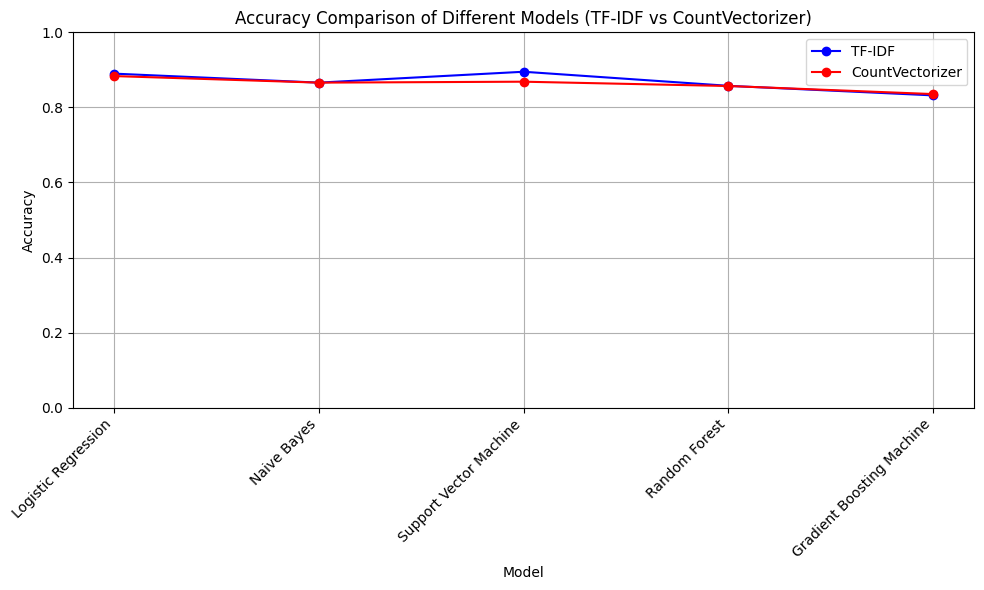

In [30]:
### Showing which vectorization method is better overall
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define models and their accuracies
models = ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine', 'Random Forest', 'Gradient Boosting Machine']
tfidf_accuracies = [accuracy_score(y_test, y_predict_lr_tf), accuracy_score(y_test, y_predict_nb_tf),
                    accuracy_score(y_test, y_predict_svm_tf), accuracy_score(y_test, y_predict_rf_tf),
                    accuracy_score(y_test, y_predict_gbm_tf)]
cv_accuracies = [accuracy_score(y_test, y_predict_lr_cv), accuracy_score(y_test, y_predict_nb_cv),
                 accuracy_score(y_test, y_predict_svm_cv), accuracy_score(y_test, y_predict_rf_cv),
                 accuracy_score(y_test, y_predict_gbm_cv)]

# Plot line chart for model accuracies
plt.figure(figsize=(10, 6))

# Plot TF-IDF accuracies
plt.plot(models, tfidf_accuracies, marker='o', linestyle='-', color='b', label='TF-IDF')

# Plot CountVectorizer accuracies
plt.plot(models, cv_accuracies, marker='o', linestyle='-', color='r', label='CountVectorizer')

plt.title('Accuracy Comparison of Different Models (TF-IDF vs CountVectorizer)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.legend()
plt.grid(True)  # Add grid for better readability
plt.tight_layout()
plt.show()

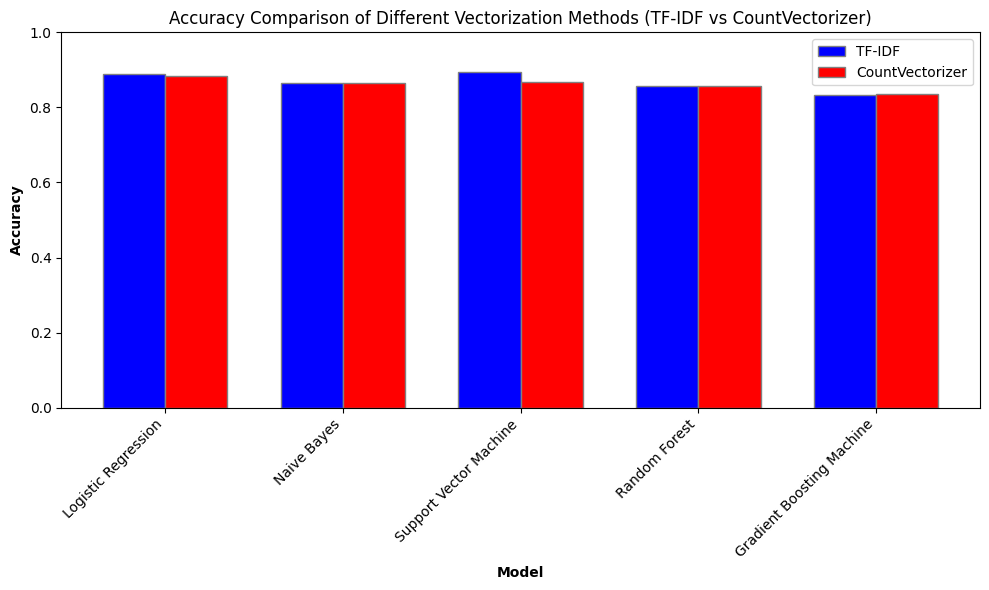

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels for the test data

# Define models and their accuracies
models = ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine', 'Random Forest', 'Gradient Boosting Machine']
tfidf_accuracies = [accuracy_score(y_test, y_predict_lr_tf), accuracy_score(y_test, y_predict_nb_tf),
                    accuracy_score(y_test, y_predict_svm_tf), accuracy_score(y_test, y_predict_rf_tf),
                    accuracy_score(y_test, y_predict_gbm_tf)]
cv_accuracies = [accuracy_score(y_test, y_predict_lr_cv), accuracy_score(y_test, y_predict_nb_cv),
                 accuracy_score(y_test, y_predict_svm_cv), accuracy_score(y_test, y_predict_rf_cv),
                 accuracy_score(y_test, y_predict_gbm_cv)]

# Set width of bar
bar_width = 0.35

# Set position of bar on X axis
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]

# Plot grouped bar chart for model accuracies
plt.figure(figsize=(10, 6))
plt.bar(r1, tfidf_accuracies, color='b', width=bar_width, edgecolor='grey', label='TF-IDF')
plt.bar(r2, cv_accuracies, color='r', width=bar_width, edgecolor='grey', label='CountVectorizer')

# Add xticks on the middle of the group bars
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(models))], models, rotation=45, ha='right')

# Create legend & Show graphic
plt.title('Accuracy Comparison of Different Vectorization Methods (TF-IDF vs CountVectorizer)')
plt.legend()
plt.ylim(0, 1)  # Set y-axis limit to ensure accuracy is between 0 and 1
plt.tight_layout()
plt.show()